In [ ]:
Major Project Title: Customer Sentiment Analysis on Flipkart Product Reviews

In [1]:
# 1.Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
#Download NLTK data:
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\SHREE\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\SHREE\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [3]:
# 2.Load Dataset
df = pd.read_csv(r"C:\Users\SHREE\OneDrive\Desktop\sentiment_project\flipkart_reviews.csv")
print(df.head())

   Unnamed: 0                                       Product_name  \
0           0  Lenovo Ideapad Gaming 3 Ryzen 5 Hexa Core 5600...   
1           1  Lenovo Ideapad Gaming 3 Ryzen 5 Hexa Core 5600...   
2           2  Lenovo Ideapad Gaming 3 Ryzen 5 Hexa Core 5600...   
3           3  DELL Inspiron Athlon Dual Core 3050U - (4 GB/2...   
4           4  DELL Inspiron Athlon Dual Core 3050U - (4 GB/2...   

                                              Review  Rating  
0  Best under 60k Great performanceI got it for a...       5  
1                                 Good perfomence...       5  
2  Great performance but usually it has also that...       5  
3           My wife is so happy and best product 👌🏻😘       5  
4  Light weight laptop with new amazing features,...       5  


In [4]:
# 3.Data Preprocessing
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)  # remove special chars
    words = text.split()
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
    return " ".join(words)

df['cleaned_review'] = df['Review'].apply(clean_text)

In [5]:
# 4. Create Sentiment Labels
def get_sentiment(rating):
    if rating >= 4:
        return "Positive"
    elif rating == 3:
        return "Neutral"
    else:
        return "Negative"

df['Sentiment'] = df['Rating'].apply(get_sentiment)

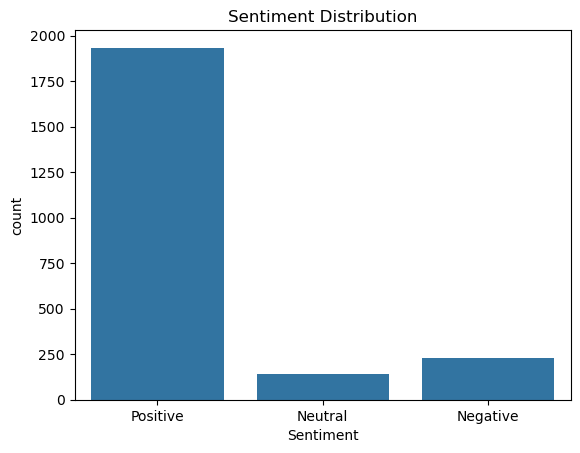

In [6]:
# 5. Exploratory Data Analysis
sns.countplot(x='Sentiment', data=df)
plt.title("Sentiment Distribution")
plt.show()

In [7]:
# 6 Convert Text to Numbers (TF-IDF)
tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df['cleaned_review']).toarray()
y = df['Sentiment']

In [8]:
# 7.Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [9]:
# 8. Train Model
model = LogisticRegression()
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


Accuracy: 0.9067245119305857

Classification Report:
               precision    recall  f1-score   support

    Negative       0.91      0.49      0.64        43
     Neutral       1.00      0.17      0.29        24
    Positive       0.91      1.00      0.95       394

    accuracy                           0.91       461
   macro avg       0.94      0.55      0.62       461
weighted avg       0.91      0.91      0.89       461



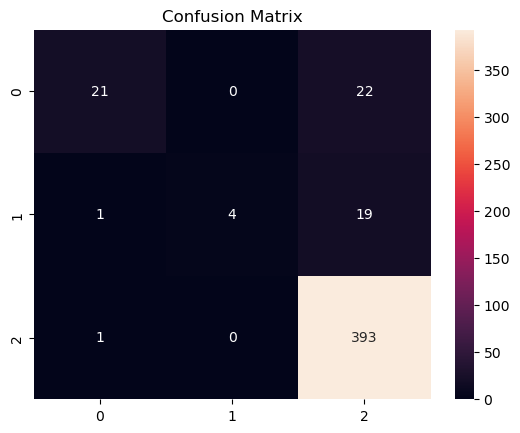

In [10]:
# 9.Evaluation
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

In [11]:
# 10.Test with New Review
def predict_sentiment(review):
    cleaned = clean_text(review)
    vector = tfidf.transform([cleaned]).toarray()
    prediction = model.predict(vector)
    return prediction[0]

print(predict_sentiment("This product is amazing and worth buying!"))

Positive
